# Jour 1 - EDA et nettoyage des données Lumina & Co

**Objectif :** auditer, nettoyer et explorer les données CRM afin de préparer la segmentation marketing du Jour 2.

Les données brutes ne sont jamais écrasées. Chaque décision de nettoyage est explicitée et les résultats sont reproduisibles en exécutant les cellules dans l'ordre.

In [1]:
# 1. Importer les bibliothèques
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("Lumina & Co - CRM")
CUSTOMERS_PATH = DATA_DIR / "customers.csv"
TRANSACTIONS_PATH = DATA_DIR / "transactions.csv"

assert CUSTOMERS_PATH.exists(), f"Fichier introuvable : {CUSTOMERS_PATH}"
assert TRANSACTIONS_PATH.exists(), f"Fichier introuvable : {TRANSACTIONS_PATH}"

print(f"pandas {pd.__version__} | données : {DATA_DIR.resolve()}")

pandas 3.0.3 | données : /Users/dorian/EDA/Lumina & Co - CRM


## 2. Charger les données

Les dates sont converties dès la lecture. Les colonnes texte répétitives utilisent le type `category` afin de limiter l'empreinte mémoire du fichier de transactions.

In [2]:
customer_dtypes = {
    "customer_id": "string",
    "country": "category",
    "n_orders": "Int64",
    "declared_preference": "category",
    "age_bracket": "category",
    "life_stage": "category",
    "urban_density": "category",
}
transaction_dtypes = {
    "invoice_id": "string",
    "customer_id": "string",
    "product_code": "string",
    "product_name": "category",
    "category": "category",
    "quantity": "int32",
    "unit_price": "float32",
    "country": "category",
}

customers_raw = pd.read_csv(
    CUSTOMERS_PATH,
    dtype=customer_dtypes,
    parse_dates=["first_purchase", "last_purchase"],
)
transactions_raw = pd.read_csv(
    TRANSACTIONS_PATH,
    dtype=transaction_dtypes,
    parse_dates=["invoice_date"],
)

print(f"Clients : {len(customers_raw):,} lignes x {customers_raw.shape[1]} colonnes")
print(f"Transactions : {len(transactions_raw):,} lignes x {transactions_raw.shape[1]} colonnes")
print(
    "Période :",
    transactions_raw["invoice_date"].min(),
    "->",
    transactions_raw["invoice_date"].max(),
)

Clients : 50,295 lignes x 13 colonnes
Transactions : 1,613,433 lignes x 9 colonnes
Période : 2022-01-07 00:00:00 -> 2026-06-30 00:00:00


## 3. Inspecter le jeu de données

Avant tout nettoyage, on documente les dimensions, les types, les valeurs manquantes et les doublons. Le rapport ci-dessous constitue le point de référence avant transformation.

In [3]:
def quality_report(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Résume types, valeurs manquantes et cardinalités."""
    return pd.DataFrame(
        {
            "type": dataframe.dtypes.astype(str),
            "valeurs_manquantes": dataframe.isna().sum(),
            "taux_manquant_pct": dataframe.isna().mean().mul(100).round(2),
            "valeurs_uniques": dataframe.nunique(dropna=False),
        }
    )

print("Aperçu clients")
display(customers_raw.head())
display(quality_report(customers_raw))

print("Aperçu transactions")
display(transactions_raw.head())
display(quality_report(transactions_raw))

print("Doublons exacts")
print(f"- clients : {customers_raw.duplicated().sum():,}")
print(f"- transactions : {transactions_raw.duplicated().sum():,}")

Aperçu clients


,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days,declared_preference,age_bracket,life_stage,urban_density
0,56396,France,2026-05-18 00:00:00,2026-06-11 00:00:00,1,757.68,757.6800,19,24,NaN,NaN,NaN,Zone urbaine dense
1,14297,France,2025-09-28 19:41:00,2026-06-12 20:16:00,4,2325.35,581.3375,17,274,NaN,NaN,NaN,NaN
2,34160,France,2024-03-25 00:00:00,2025-06-03 00:00:00,1,519.12,519.1200,392,435,Peau sèche,45-54 ans,NaN,NaN
3,61352,France,2023-06-21 00:00:00,2025-03-02 00:00:00,4,6394.33,1598.5800,485,620,Peau sèche,35-44 ans,Jeune actif en solo,NaN
4,20612,France,2025-09-19 00:00:00,2026-06-17 00:00:00,9,5918.34,657.5900,13,271,NaN,NaN,NaN,NaN


,type,valeurs_manquantes,taux_manquant_pct,valeurs_uniques
customer_id,string,0,0.00,50295
country,category,0,0.00,41
first_purchase,datetime64[us],0,0.00,7334
last_purchase,datetime64[us],0,0.00,6521
n_orders,Int64,0,0.00,86
total_spent,float64,0,0.00,47853
avg_basket,float64,0,0.00,43518
recency_days,int64,0,0.00,842
tenure_days,int64,0,0.00,849
declared_preference,category,31108,61.85,8


Aperçu transactions


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
0,509453,13381,82583,Savon Surgras Lavande,Corps,3,7.720000,2024-12-12 20:59:00,France
1,558926,17469,23201,Lait Corps Amande Douce,Corps,1,18.209999,2026-01-23 21:31:00,France
2,567853,15484,23289,Savon Surgras Lavande,Corps,1,7.530000,2026-04-13 00:41:00,France
3,549949,13208,22289,Huile Démaquillante Camélia,Visage,1,22.840000,2025-11-02 00:07:00,France
4,505081,16742,22607,Coffret Découverte Rituel Slow Beauty,Coffret,1,47.119999,2024-11-08 20:59:00,France


,type,valeurs_manquantes,taux_manquant_pct,valeurs_uniques
invoice_id,string,0,0.00,247690
customer_id,string,367328,22.77,49403
product_code,string,0,0.00,5305
product_name,category,2241,0.14,36
category,category,0,0.00,7
quantity,int32,0,0.00,10
unit_price,float32,0,0.00,3839
invoice_date,datetime64[us],0,0.00,48982
country,category,0,0.00,43


Doublons exacts
- clients : 0
- transactions : 445


### Rapport qualité initial : 5 observations clés

1. **Identifiants clients manquants :** 367 328 lignes de transactions (22,77 %) ne peuvent pas être rattachées à un client. Elles restent utiles pour le chiffre d'affaires global, mais seront exclues des analyses client/RFM.
2. **Retours et annulations :** les quantités négatives doivent être conservées pour calculer un chiffre d'affaires net; elles ne représentent pas des ventes classiques.
3. **Prix nuls ou négatifs :** les lignes gratuites peuvent correspondre à des cadeaux ou échantillons. Les prix négatifs sont considérés comme invalides et isolés.
4. **Doublons :** 445 lignes de transactions sont strictement identiques. Elles seront supprimées avant agrégation pour éviter un double comptage.
5. **Biais de couverture :** la France représente plus de 90 % des clients et les variables zero-party sont manquantes pour 57 % à 80 % des profils. Les résultats géographiques et déclaratifs ne sont donc pas généralisables sans prudence.

In [4]:
# Quantification des anomalies avant nettoyage
anomaly_report = pd.Series(
    {
        "customer_id manquant": transactions_raw["customer_id"].isna().sum(),
        "quantité négative": transactions_raw["quantity"].lt(0).sum(),
        "prix nul": transactions_raw["unit_price"].eq(0).sum(),
        "prix négatif": transactions_raw["unit_price"].lt(0).sum(),
        "product_name manquant": transactions_raw["product_name"].isna().sum(),
        "doublon exact": transactions_raw.duplicated().sum(),
        "dates client inversées": customers_raw["first_purchase"].gt(customers_raw["last_purchase"]).sum(),
        "total client négatif": customers_raw["total_spent"].lt(0).sum(),
    },
    name="nombre_de_lignes",
).to_frame()
anomaly_report["part_transactions_pct"] = (
    anomaly_report["nombre_de_lignes"].div(len(transactions_raw)).mul(100).round(2)
)
display(anomaly_report)

atypical_codes = transactions_raw.loc[
    ~transactions_raw["product_code"].str.fullmatch(r"\d+[A-Z]?", na=False),
    "product_code",
].value_counts().head(20)
print("Codes produit atypiques les plus fréquents :")
display(atypical_codes.to_frame("nombre_de_lignes"))

,nombre_de_lignes,part_transactions_pct
customer_id manquant,367328,22.77
quantité négative,34691,2.15
prix nul,10897,0.68
prix négatif,177,0.01
product_name manquant,2241,0.14
doublon exact,445,0.03
dates client inversées,0,0.00
total client négatif,0,0.00


Codes produit atypiques les plus fréquents :


,nombre_de_lignes
product_code,
POST,2176
DOT,1496
M,1475
15056BL,980
C2,337
79323LP,296
D,235
79323GR,173
S,170


## 4. Nettoyer les données

### Décisions de traitement

- Les doublons stricts sont supprimés.
- Les identifiants restent des chaînes : ce sont des clés, pas des mesures.
- Les codes produit sont normalisés en majuscules.
- Les transactions anonymes sont conservées dans la table nettoyée générale, mais exclues de la vue client.
- Les quantités négatives sont marquées comme retours et conservées pour le chiffre d'affaires net.
- Les lignes à prix nul sont marquées comme gratuites; les prix négatifs sont exclus des vues de vente.
- Les frais et écritures comptables (`POST`, `DOT`, `M`, `BANK CHARGES`, `ADJUST`, etc.) sont marqués comme non-produits.
- Les données zero-party manquantes ne sont pas imputées : inventer une préférence client créerait un biais.

In [5]:
NON_PRODUCT_CODES = {
    "POST", "DOT", "M", "D", "S", "C2", "BANK CHARGES", "ADJUST",
}

customers = customers_raw.drop_duplicates().copy()
transactions = transactions_raw.drop_duplicates().copy()
transactions["product_code"] = transactions["product_code"].str.upper()
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
transactions["is_return"] = transactions["quantity"].lt(0)
transactions["is_free"] = transactions["unit_price"].eq(0)
transactions["is_invalid_price"] = transactions["unit_price"].lt(0)
transactions["is_non_product"] = (
    transactions["product_code"].isin(NON_PRODUCT_CODES)
    | transactions["category"].eq("Frais")
)

# Ventes positives pour paniers et produits; les retours restent dans `transactions`.
sales = transactions.loc[
    transactions["quantity"].gt(0)
    & transactions["unit_price"].gt(0)
    & ~transactions["is_non_product"]
].copy()
customer_sales = sales.dropna(subset=["customer_id"]).copy()

assert customers["customer_id"].is_unique
assert not transactions.duplicated().any()
assert (customers["first_purchase"] <= customers["last_purchase"]).all()
assert sales["line_total"].gt(0).all()

cleaning_summary = pd.Series(
    {
        "lignes brutes": len(transactions_raw),
        "lignes après dédoublonnage": len(transactions),
        "ventes produit positives": len(sales),
        "ventes produit rattachées à un client": len(customer_sales),
        "retours conservés dans transactions": transactions["is_return"].sum(),
        "lignes gratuites conservées et marquées": transactions["is_free"].sum(),
        "lignes non-produit conservées et marquées": transactions["is_non_product"].sum(),
    },
    name="volume",
)
display(cleaning_summary.to_frame())

,volume
lignes brutes,1613433
lignes après dédoublonnage,1612988
ventes produit positives,1566233
ventes produit rattachées à un client,1211343
retours conservés dans transactions,34554
lignes gratuites conservées et marquées,10605
lignes non-produit conservées et marquées,7746


## 5. Explorer les statistiques descriptives

Cette section décrit les variables, puis calcule les indicateurs utiles au marketing : panier, fréquence, concentration du chiffre d'affaires, saisonnalité, géographie, catégories et couverture zero-party.

In [6]:
numeric_columns = ["n_orders", "total_spent", "avg_basket", "recency_days", "tenure_days"]
categorical_columns = ["country", "declared_preference", "age_bracket", "life_stage", "urban_density"]

print("Statistiques numériques des clients")
display(customers[numeric_columns].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T)

print("Statistiques catégorielles des clients")
display(customers[categorical_columns].describe().T)

single_purchase_rate = customers["n_orders"].eq(1).mean()
print(f"Clients avec une seule commande : {single_purchase_rate:.1%}")
print(f"Clients récurrents : {1 - single_purchase_rate:.1%}")

Statistiques numériques des clients


,count,mean,std,min,50%,75%,90%,95%,99%,max
n_orders,50295.0,4.586042,5.877529,1.0,3.0,6.0,11.0,14.0,20.0,373.0
total_spent,50295.0,3373.702775,6004.065658,5.37,1597.36,3950.63,8386.708,12269.044,23463.1904,416440.59
avg_basket,50295.0,724.183056,656.605537,5.37,560.96,921.62,1480.196,1926.742,3171.386,11891.23
recency_days,50295.0,207.130609,210.571335,0.0,109.0,376.0,534.0,626.0,738.0,846.0
tenure_days,50295.0,463.081261,226.265579,0.0,503.0,649.0,728.6,763.0,820.0,848.0


Statistiques catégorielles des clients


,count,unique,top,freq
country,50295,41,France,45904
declared_preference,19187,7,Peau sensible,2815
age_bracket,21474,5,18-24 ans,4392
life_stage,11309,5,Parent de jeunes enfants,2337
urban_density,9963,3,Zone urbaine dense,3370


Clients avec une seule commande : 28.8%
Clients récurrents : 71.2%


In [7]:
# Paniers par facture et concentration du chiffre d'affaires client
orders = (
    customer_sales.groupby("invoice_id", observed=True)
    .agg(
        customer_id=("customer_id", "first"),
        invoice_date=("invoice_date", "max"),
        country=("country", "first"),
        basket_total=("line_total", "sum"),
    )
    .reset_index()
)

customer_value = customers[["customer_id", "total_spent"]].sort_values("total_spent", ascending=False)
customer_value["cumulative_revenue_share"] = customer_value["total_spent"].cumsum() / customer_value["total_spent"].sum()
clients_for_80 = int(customer_value["cumulative_revenue_share"].searchsorted(0.80) + 1)
clients_for_80_rate = clients_for_80 / len(customer_value)

print(f"Panier médian : {orders['basket_total'].median():,.2f} €")
print(f"Panier moyen : {orders['basket_total'].mean():,.2f} €")
print(f"Part des clients générant 80 % du CA : {clients_for_80_rate:.1%} ({clients_for_80:,} clients)")

zero_party_columns = ["declared_preference", "age_bracket", "life_stage", "urban_density"]
zero_party_coverage = customers[zero_party_columns].notna().mean().mul(100).round(1)
display(zero_party_coverage.rename("taux_remplissage_pct").to_frame())

Panier médian : 75.52 €
Panier moyen : 185.76 €
Part des clients générant 80 % du CA : 34.3% (17,267 clients)


,taux_remplissage_pct
declared_preference,38.1
age_bracket,42.7
life_stage,22.5
urban_density,19.8


In [8]:
# Tables d'agrégation pour les analyses marketing
revenue_transactions = transactions.loc[
    ~transactions["is_invalid_price"] & ~transactions["is_non_product"]
].copy()
monthly_revenue = (
    revenue_transactions.set_index("invoice_date")["line_total"]
    .resample("MS")
    .sum()
    .rename("net_revenue")
)

country_summary = (
    customers.groupby("country", observed=True)
    .agg(
        clients=("customer_id", "nunique"),
        panier_moyen=("avg_basket", "mean"),
        frequence_moyenne=("n_orders", "mean"),
    )
    .sort_values("clients", ascending=False)
)
country_summary["part_clients_pct"] = country_summary["clients"].div(len(customers)).mul(100)

category_revenue = (
    sales.groupby("category", observed=True)["line_total"]
    .sum()
    .sort_values(ascending=False)
)

correlations = customers[numeric_columns].corr(method="spearman")
print("Principaux pays")
display(country_summary.head(10).round(2))
print("Chiffre d'affaires positif par catégorie")
display(category_revenue.to_frame("revenue").round(2))
print(f"Corrélation de Spearman récence / montant : {correlations.loc['recency_days', 'total_spent']:.3f}")
print(f"Corrélation de Spearman fréquence / panier moyen : {correlations.loc['n_orders', 'avg_basket']:.3f}")

Principaux pays


,clients,panier_moyen,frequence_moyenne,part_clients_pct
country,,,,
France,45904,714.26,4.61,91.27
Germany,918,806.84,5.03,1.83
United Kingdom,760,730.32,4.82,1.51
Spain,291,788.80,3.39,0.58
Portugal,211,845.20,3.58,0.42
Belgium,203,644.35,5.65,0.40
Switzerland,184,1414.67,3.97,0.37
Sweden,171,852.76,2.64,0.34
Netherlands,166,577.12,4.04,0.33


Chiffre d'affaires positif par catégorie


,revenue
category,
Visage,16477488.54
Corps,10705002.04
Coffret,10638970.62
Cheveux,5863554.11
Accessoire,4197442.48
Bain,3680447.21


Corrélation de Spearman récence / montant : -0.449
Corrélation de Spearman fréquence / panier moyen : 0.093


## 6. Visualiser les distributions

Les axes des distributions sont limités au 99e percentile pour rendre visibles les comportements majoritaires sans supprimer les valeurs extrêmes des données. Les statistiques précédentes conservent, elles, l'ensemble des observations.

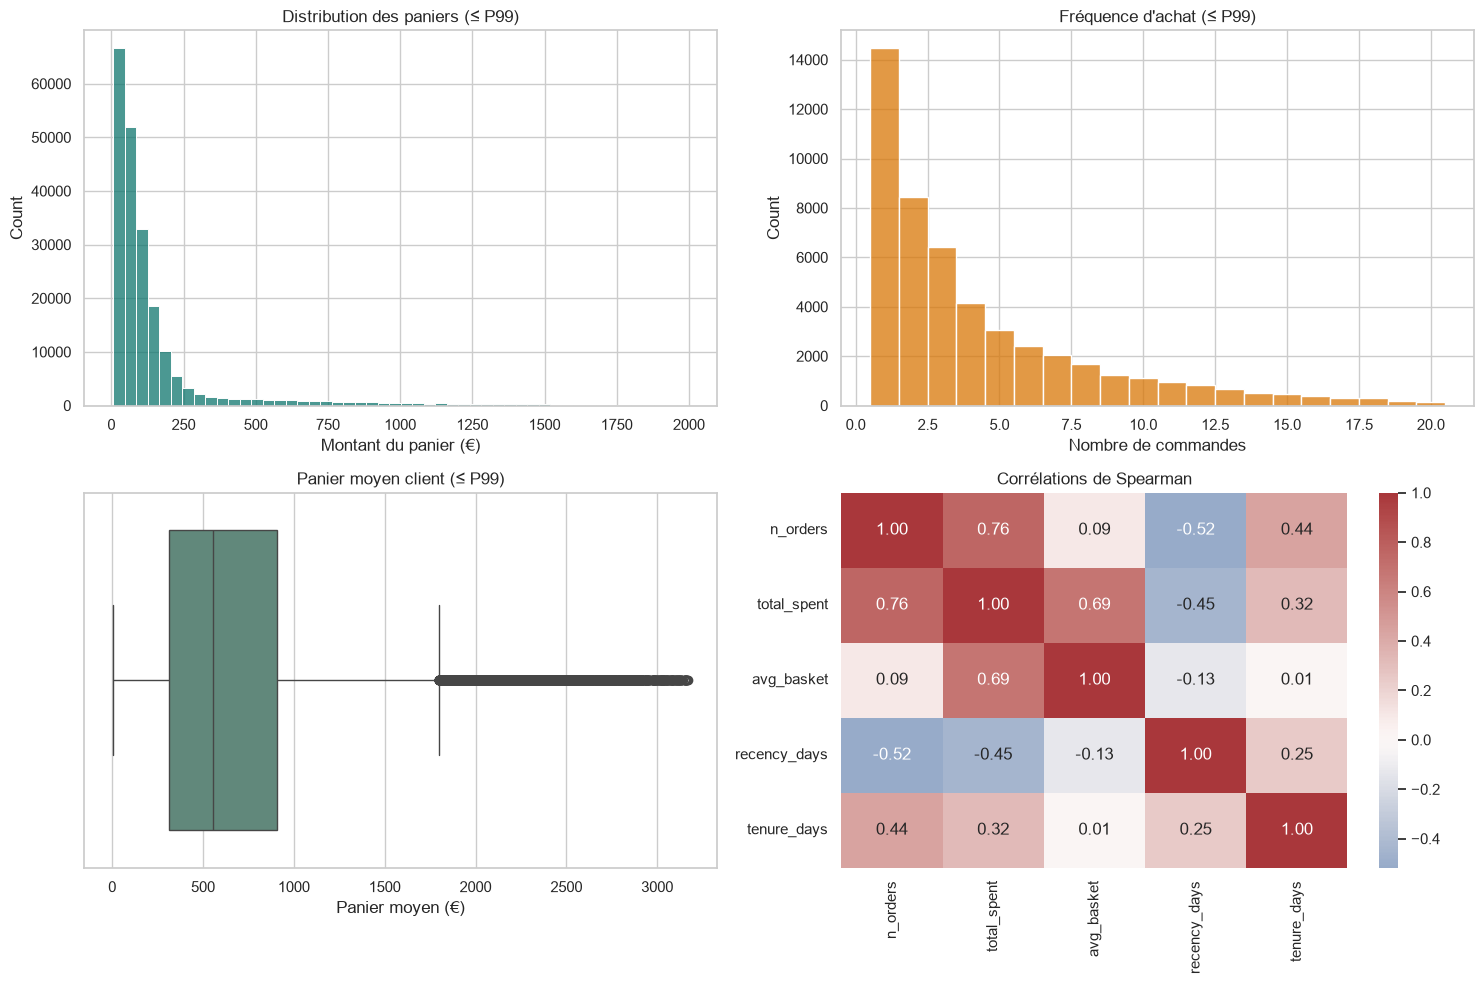

In [9]:
basket_limit = orders["basket_total"].quantile(0.99)
frequency_limit = customers["n_orders"].quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(
    orders.loc[orders["basket_total"] <= basket_limit, "basket_total"],
    bins=50,
    ax=axes[0, 0],
    color="#0F766E",
)
axes[0, 0].set(title="Distribution des paniers (≤ P99)", xlabel="Montant du panier (€)")

sns.histplot(
    customers.loc[customers["n_orders"] <= frequency_limit, "n_orders"],
    discrete=True,
    ax=axes[0, 1],
    color="#D97706",
)
axes[0, 1].set(title="Fréquence d'achat (≤ P99)", xlabel="Nombre de commandes")

sns.boxplot(
    x=customers.loc[customers["avg_basket"] <= customers["avg_basket"].quantile(0.99), "avg_basket"],
    ax=axes[1, 0],
    color="#5B8E7D",
)
axes[1, 0].set(title="Panier moyen client (≤ P99)", xlabel="Panier moyen (€)")

sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Corrélations de Spearman")

fig.tight_layout()
plt.show()

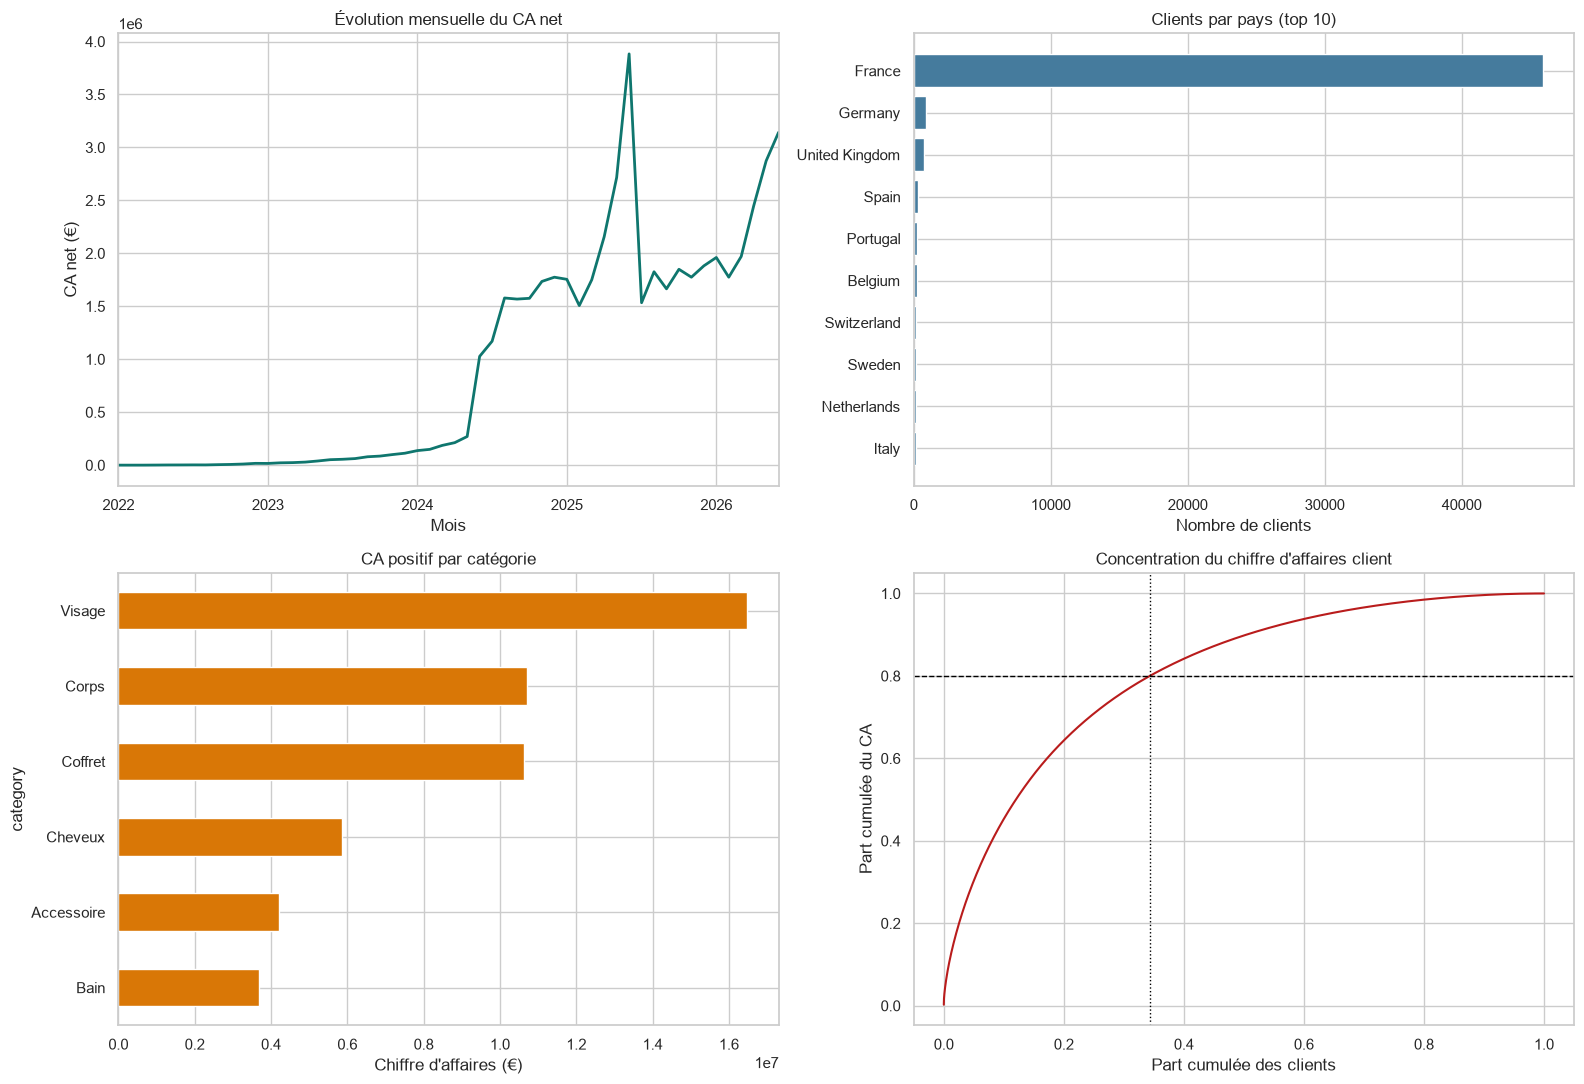

Six mois au CA net le plus élevé :


,net_revenue
invoice_date,
2025-06-01,3883190.37
2026-06-01,3142758.58
2026-05-01,2872775.36
2025-05-01,2716279.06
2026-04-01,2447688.93
2025-04-01,2157330.44


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

monthly_revenue.plot(ax=axes[0, 0], color="#0F766E", linewidth=2)
axes[0, 0].set(title="Évolution mensuelle du CA net", xlabel="Mois", ylabel="CA net (€)")

top_countries = country_summary.head(10).sort_values("clients")
axes[0, 1].barh(top_countries.index.astype(str), top_countries["clients"], color="#457B9D")
axes[0, 1].set(title="Clients par pays (top 10)", xlabel="Nombre de clients")

category_revenue.sort_values().plot(kind="barh", ax=axes[1, 0], color="#D97706")
axes[1, 0].set(title="CA positif par catégorie", xlabel="Chiffre d'affaires (€)")

pareto_x = np.arange(1, len(customer_value) + 1) / len(customer_value)
axes[1, 1].plot(pareto_x, customer_value["cumulative_revenue_share"], color="#B91C1C")
axes[1, 1].axhline(0.8, color="black", linestyle="--", linewidth=1)
axes[1, 1].axvline(clients_for_80_rate, color="black", linestyle=":", linewidth=1)
axes[1, 1].set(
    title="Concentration du chiffre d'affaires client",
    xlabel="Part cumulée des clients",
    ylabel="Part cumulée du CA",
)

fig.tight_layout()
plt.show()

print("Six mois au CA net le plus élevé :")
display(monthly_revenue.nlargest(6).to_frame().round(2))

## Hypothèses marketing à tester au Jour 2

1. **Réactivation :** la corrélation négative entre récence et montant dépensé suggère que les clients récemment actifs ont davantage de valeur. Un segment RFM à forte valeur mais devenu inactif devrait répondre à une campagne de réactivation personnalisée.
2. **Deuxième achat :** 28,8 % des clients n'ont commandé qu'une fois. Une séquence post-achat orientée vers une deuxième commande pourrait augmenter la rétention précoce.
3. **Traitement différencié des meilleurs clients :** 34,3 % des clients génèrent 80 % du chiffre d'affaires. Ces clients devraient recevoir des avantages de fidélité plutôt que des remises indifférenciées.
4. **Affinité produit :** la catégorie Visage domine le chiffre d'affaires. Les segments RFM achetant Visage pourraient présenter un potentiel de vente croisée vers Corps ou Coffret.
5. **Collecte progressive de données :** le faible remplissage des données zero-party (19,8 % à 42,7 %) suggère de tester une collecte progressive avec une contrepartie claire, plutôt que de les utiliser seules pour personnaliser les campagnes.

### Limites à conserver dans la restitution

- La France représente 91,3 % des profils : les comparaisons entre pays reposent parfois sur de faibles effectifs.
- Les transactions anonymes ne permettent pas d'analyser le parcours ou la valeur client.
- Les retours sont inclus dans le chiffre d'affaires net, mais exclus des distributions de paniers positifs.
- Les seuils d'outliers servent uniquement à la lisibilité des graphiques; aucune valeur extrême n'est supprimée des tables sources.